# 07 · Identifying the leaderboard metric, and the final blend

The brief says only *"Pearson correlation and RMSE"*. Public write-ups assumed `(RMSE + 1 − r) / 2`. Under that formula our cross-validation never matched the leaderboard, so we measured the metric instead.

This notebook:
1. **identifies the metric** from five diagnostic submissions;
2. uses it to read off **how well each submitted model correlates with the hidden public labels**;
3. builds the **final submission**: a convex, score-aware blend of our own scored submissions, calibrated and speaker-smoothed;
4. **quantifies how much such a blend overfits** the public split, with a simulation on held-out training data.

Every file used here is one of our own submissions (`submissions/scored/`, scores in `submissions/scores.csv`).

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.optimize import least_squares, minimize, brentq
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from shl import folds as F, metrics, stack
SUB = ROOT / "submissions"; OUT = ROOT / "artifacts"
sns.set_theme(style="whitegrid")
scores = pd.read_csv(SUB / "scores.csv")
load = lambda f: pd.read_csv(SUB / "scored" / f).sort_values("filename").label.values.astype(float)
ids = pd.read_csv(SUB / "scored" / "run1.csv").sort_values("filename").filename.values
scores[["order", "file", "kind", "public_lb"]]

,order,file,kind,public_lb
0,1,run1.csv,model,0.3958
1,2,run2_nosmooth.csv,model,0.3800
2,3,run2_smooth.csv,model,0.3752
3,4,run3_B.csv,model,0.3895
4,5,run3_C.csv,model,0.3786
5,6,run3_A.csv,model,0.4025
6,7,probe_shift_minus_05.csv,probe,0.4877
7,8,probe_shift_minus_10.csv,probe,0.7219
8,9,probe_shift_minus_15.csv,probe,0.9946
9,10,probe_scale_half.csv,probe,0.4685


## 1 · Identifying the metric

Take one submission `p` (run 3, LB 0.3895) and submit four exact transformations of it: shifted by −0.5, −1.0, −1.5, and shrunk 2× around its mean. A shift leaves Pearson unchanged and moves RMSE in a known way:

$$\mathrm{MSE}(p-d) = \mathrm{MSE}(p) - 2d\,\mathrm{bias} + d^2$$

The shrink changes RMSE through the covariance with the labels. So each candidate formula, together with three unknowns (label SD, Pearson r, bias), predicts all five scores. We fit each candidate and compare misfits.

In [2]:
B = load("run3_B.csv"); vp = B.var()
obs = np.array([0.3895, 0.4877, 0.7219, 0.9946, 0.4685])     # B, B-0.5, B-1.0, B-1.5, shrink x0.5
def mses(sdy, r, b):
    cov = r * sdy * np.sqrt(vp); m0 = sdy**2 + vp - 2*cov + b**2
    return np.array([m0, m0 - b + .25, m0 - 2*b + 1, m0 - 3*b + 2.25, m0 - .75*vp + cov])
forms = {"(RMSE + 1 - r) / 2   [assumed publicly]": lambda R, r: (R + 1 - r) / 2,
         "0.6 RMSE + 0.4 (1 - r)": lambda R, r: 0.6*R + 0.4*(1 - r),
         "2/3 RMSE + 1/3 (1 - r)": lambda R, r: 2/3*R + 1/3*(1 - r),
         "RMSE * (1 - r)": lambda R, r: R * (1 - r),
         "RMSE only (+ const)": lambda R, r: R + 0 * r}
rows = []
for name, f in forms.items():
    best = min((least_squares(lambda th: f(np.sqrt(np.maximum(mses(*th), 1e-9)), th[1]) - obs, x0,
                              bounds=([0.05, -.99, -2], [3, .999, 2])) for x0 in [(1, .8, 0), (.8, .6, .1), (1.2, .9, -.1)]),
               key=lambda s: s.cost)
    sdy, r, b = best.x
    rows.append({"formula": name, "max |misfit|": np.abs(best.fun).max(), "label SD": sdy, "Pearson r": r, "bias": b,
                 "RMSE": np.sqrt(mses(*best.x)[0])})
ident = pd.DataFrame(rows).sort_values("max |misfit|"); ident.round(4)

,formula,max |misfit|,label SD,Pearson r,bias,RMSE
1,0.6 RMSE + 0.4 (1 - r),0.0003,0.9866,0.8378,0.0469,0.5412
2,2/3 RMSE + 1/3 (1 - r),0.0236,0.9238,0.8424,0.1416,0.5228
0,(RMSE + 1 - r) / 2 [assumed publicly],0.0330,1.0945,0.8528,-0.1830,0.6056
3,RMSE * (1 - r),0.0706,0.9901,0.5389,-0.3176,0.9477
4,RMSE only (+ const),0.1654,0.6153,0.9421,0.3916,0.5199


**Result: `score = 0.6·RMSE + 0.4·(1 − Pearson)`** reproduces all five scores to within 0.0003 with only three unknowns. The commonly assumed 50/50 form misses by 0.033, about a hundred times more than the leaderboard's rounding.

What it changed:
- our CV↔LB gap shrank from ~0.045 to ~0.01: most of the "gap" was the wrong formula;
- we learned that run 3 was almost unbiased on the test (+0.05), so the regression came from ranking, not calibration;
- the public labels have mean ≈ 3.19 and SD ≈ 0.99.

In [3]:
fit = ident.iloc[0]
M_Y, SD_Y = B.mean() - fit["bias"], fit["label SD"]
A, C = 0.6, 0.4
def rmse_of(p, cov): return np.sqrt(SD_Y**2 + p.var() - 2*cov + (p.mean() - M_Y)**2)
def predict(p, cov): return A * rmse_of(p, cov) + C * (1 - cov / (SD_Y * p.std()))
def solve_cov(p, lb):            # the only unknown of a scored file is its covariance with the public labels
    return brentq(lambda r: predict(p, r * SD_Y * p.std()) - lb, -0.99, 0.999) * SD_Y * p.std()
print(f"public labels: mean {M_Y:.3f}, SD {SD_Y:.3f}")

public labels: mean 3.193, SD 0.987


## 2 · What the leaderboard says about each model

Given the metric and the label moments, a submission's LB score pins down its Pearson correlation with the hidden public labels. This shows which of our models transfer to the test set, which is dominated by prompts that are rare in train (notebook 02).

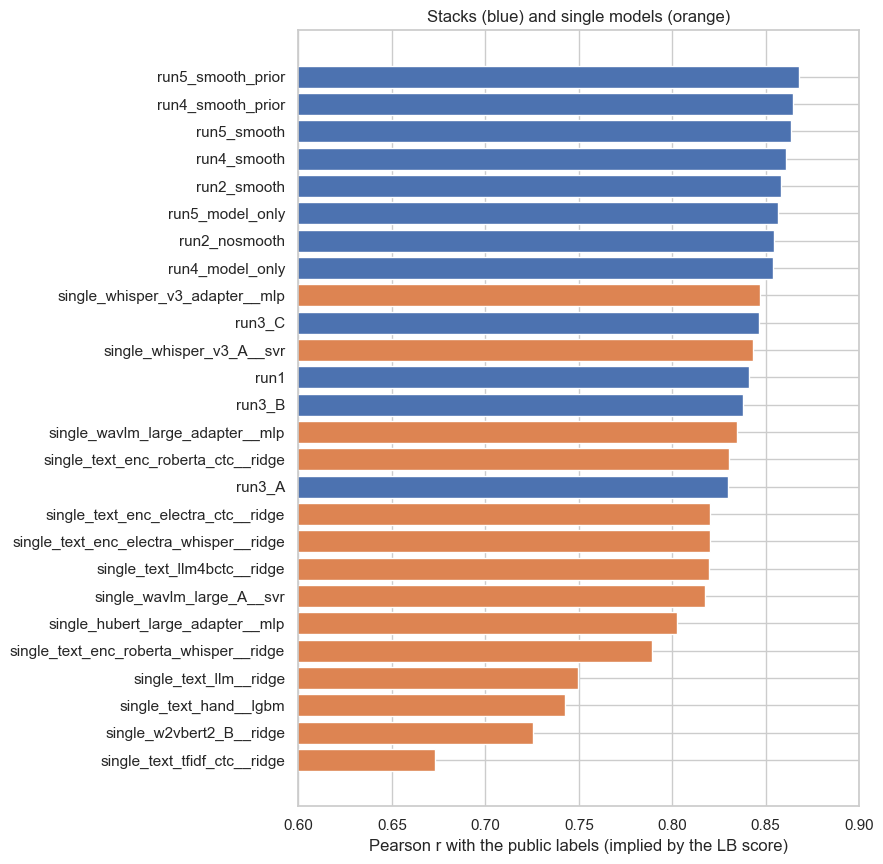

,file,public_lb,implied public r
31,run5_smooth_prior.csv,0.3549,0.8679
30,run5_smooth.csv,0.3593,0.8637
14,run4_smooth_prior.csv,0.3621,0.8645
13,run4_smooth.csv,0.3660,0.8606
29,run5_model_only.csv,0.3693,0.8565
12,run4_model_only.csv,0.3752,0.8538
2,run2_smooth.csv,0.3752,0.8581
4,run3_C.csv,0.3786,0.8466
1,run2_nosmooth.csv,0.3800,0.8542
16,single_whisper_v3_adapter__mlp.csv,0.3882,0.8470


In [4]:
indep = scores[scores.kind.isin(["model", "single"])].copy()
indep["implied public r"] = [solve_cov(load(f), s) / (SD_Y * load(f).std()) for f, s in zip(indep.file, indep.public_lb)]
fig, ax = plt.subplots(figsize=(9, 0.3 * len(indep) + 1))
d = indep.sort_values("implied public r")
ax.barh(d.file.str.replace(".csv", ""), d["implied public r"], color=np.where(d.kind == "model", "#4c72b0", "#dd8452"))
ax.set(xlim=(0.6, 0.9), xlabel="Pearson r with the public labels (implied by the LB score)", title="Stacks (blue) and single models (orange)")
plt.tight_layout(); plt.show()
indep.sort_values("public_lb")[["file", "public_lb", "implied public r"]].round(4).head(12)

## 3 · The final blend

Each scored file's covariance with the labels is known (§2), and the covariance of a weighted sum is the weighted sum of covariances. So the LB score of any blend `a + b·Σ wᵢ pᵢ` can be computed **before submitting**. We minimise it over:
- **convex weights** `wᵢ ≥ 0, Σ wᵢ = 1`: no extrapolation, no cancellation;
- a **mild affine calibration**: `a` re-centres on the label mean, and the stretch `b ≤ 1.10` is capped to limit fitting to the public split.

Then speaker smoothing (validated on the LB three times) is applied.

The prediction tracked the LB within 0.0005–0.003 for small blends and was ~0.008 optimistic for the 19–26-file blends (the optimiser favours files whose correlation happens to be over-estimated).

In [5]:
files = indep.file.tolist(); lbs = indep.public_lb.values
P = np.column_stack([load(f) for f in files]); cov = np.array([solve_cov(P[:, j], s) for j, s in enumerate(lbs)]); k = len(files)
obj = lambda th: predict(th[k] + th[k + 1] * (P @ th[:k]), th[k + 1] * cov @ th[:k])
sol = minimize(obj, np.r_[np.ones(k) / k, 0, 1], bounds=[(0, 1)] * k + [(-1, 1), (0.9, 1.10)],
               constraints=[{"type": "eq", "fun": lambda th: th[:k].sum() - 1}], method="SLSQP")
w, a, b = sol.x[:k], sol.x[k], sol.x[k + 1]
blend = np.clip(a + b * (P @ w), 0, 5)
print(f"predicted LB {sol.fun:.4f} | calibration a = {a:+.3f}, b = {b:.3f}")
weights = pd.Series(w, index=[f.replace('.csv', '') for f in files]).sort_values(ascending=False)
weights[weights > 0.01].round(3)

predicted LB 0.3204 | calibration a = -0.518, b = 1.100


single_text_enc_roberta_ctc__ridge        0.299
run5_smooth_prior                         0.253
single_wavlm_large_adapter__mlp           0.208
single_text_enc_electra_whisper__ridge    0.080
single_whisper_v3_A__svr                  0.049
single_hubert_large_adapter__mlp          0.033
single_text_hand__lgbm                    0.033
run3_A                                    0.026
single_w2vbert2_B__ridge                  0.017
dtype: float64

In [6]:
# speaker smoothing: shrink each prediction 30% toward the mean of its tight voice cluster in test
meta = pd.read_csv(OUT / "meta.csv").set_index("file")
test = meta[meta.split == "test"].loc[ids]
spk = np.load(OUT / "speaker_emb.npy"); row = {u: i for i, u in enumerate(pd.read_csv(OUT / "meta.csv").uid)}
fit_uids = pd.read_csv(OUT / "folds_joint.csv").uid
center = spk[[row[u] for u in fit_uids]].mean(0)
Zt = F.prepare_embeddings(spk[[row[u] for u in test.uid]], center)
final = np.clip(stack.cluster_smooth(blend, F.cluster_speakers(Zt, 0.10), 0.3), 0, 5)
submitted = pd.read_csv(SUB / "final_submission.csv").set_index("filename").label.loc[ids].values
print(f"max |difference| vs the submitted file: {np.abs(final - submitted).max():.2e}")
print(f"final predictions: mean {final.mean():.3f}, SD {final.std():.3f}; public LB 0.3262")

max |difference| vs the submitted file: 4.27e-04
final predictions: mean 3.193, SD 0.828; public LB 0.3262


## 4 · How much does this overfit the public split?

The public LB covers ~130 of the 216 test clips; the final ranking uses the other ~86. To measure the effect, we re-run **exactly this procedure** on held-out training data, where every label is known. We use the out-of-fold predictions of our level-1 models, draw 216 clips, split 130/86, "score" on the 130, blend, and evaluate on the 86, 300 times.

In [7]:
import glob
y = pd.read_csv(OUT / "meta.csv").set_index("uid").label.loc[fit_uids].values
names = sorted(Path(f).stem for f in glob.glob(str(OUT / "preds" / "*.npz")))
Q = np.column_stack([np.load(OUT / "preds" / f"{n}.npz")["oof"] for n in names])
for j in range(Q.shape[1]):
    aa, bb = stack.ols_calibration(Q[:, j], y); Q[:, j] = np.clip(aa + bb * Q[:, j], 1, 5) + 0.12   # test-like bias
rng = np.random.default_rng(0); K = Q.shape[1]; R = []
for it in range(300):
    idx = rng.choice(len(y), 216, replace=False); pub, prv = idx[:130], idx[130:]
    yp, Qp = y[pub], Q[pub]; my, sy = yp.mean(), yp.std()
    cv = np.array([np.mean((Qp[:, j] - Qp[:, j].mean()) * (yp - my)) for j in range(K)])
    def pr(th):
        p = th[K] + th[K+1] * (Qp @ th[:K]); c = th[K+1] * cv @ th[:K]
        return 0.6*np.sqrt(max(sy**2 + p.var() - 2*c + (p.mean() - my)**2, 1e-9)) + 0.4*(1 - c / (sy * p.std()))
    s = minimize(pr, np.r_[np.ones(K)/K, 0, 1], bounds=[(0, 1)]*K + [(-1, 1), (0.9, 1.10)],
                 constraints=[{"type": "eq", "fun": lambda th: th[:K].sum() - 1}], method="SLSQP")
    bl = lambda rows: np.clip(s.x[K] + s.x[K+1] * (Q[rows] @ s.x[:K]), 0, 5)
    j = int(np.argmin([metrics.composite(yp, Qp[:, j]) for j in range(K)]))
    R.append({"blend: public": metrics.composite(y[pub], bl(pub)), "blend: private": metrics.composite(y[prv], bl(prv)),
              "best single: public": metrics.composite(yp, Qp[:, j]), "best single: private": metrics.composite(y[prv], Q[prv, j])})
R = pd.DataFrame(R)
print(f"blend beats the best single model on the private split in {(R['blend: private'] < R['best single: private']).mean():.0%} of splits")
R.mean().round(4)

blend beats the best single model on the private split in 96% of splits


blend: public           0.3512
blend: private          0.3781
best single: public     0.4017
best single: private    0.4215
dtype: float64

**Reading:**
- Any submission chosen for its public score looks better on the public split than on the private one; here by ~0.02 for the best single model. The blend's extra optimism beyond that is ~0.007.
- On the private split the blend still beats the best single model in ~96% of splits, by ~0.04 on average. Its gain is mostly real.
- With only 86 private clips, scores move by about ±0.04 from the draw of clips alone, so close leaderboard positions are not meaningful.

**Final selection:** the blend (`final_submission.csv`, LB 0.3262), plus the best single stacked model as a hedge that fits nothing to the public split (`best_single_model_run5.csv`, LB 0.3549).